# Land Cover Mapping

In this tutorial we map land cover from a small set of training points using the
scikit-map machinery. The whole workflow runs on the **toy dataset** bundled with
the library, so no additional download is required.

The pipeline has three steps:

1. **Space-time overlay** — extract the raster covariate values at each training point.
2. **Training** — fit a scikit-learn classifier on the overlaid table.
3. **Prediction** — apply the model to every pixel of the toy raster to produce a map.


## Setup

We start by importing the modules used in this tutorial.

In [ ]:
import os

os.environ["PROJ_LIB"] = "/skmap/lib/python3.12/site-packages/rasterio/proj_data"
os.environ["PROJ_DATA"] = "/skmap/lib/python3.12/site-packages/rasterio/proj_data"

In [1]:
import warnings

warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

from skmap.catalog import DataCatalog
from skmap.data import toy
from skmap.overlay import SpaceTimeOverlay


## Dataset

The toy dataset ships a set of **land-cover training points** (`samples.gpkg`) and a
few raster layers covering the same 256 x 256 grid (EPSG:3035):

- `static/elev` and `static/slope` — static terrain layers,
- `ndvi/filled` and `swir1` — quarterly Landsat composites (2014-2020).

Let's load the training points.

In [2]:
samples = toy.lc_samples()
samples.head()


,date,label,code,target,geometry
0,2019-01-01,Non-irrigated arable land,211,12,POINT (4027365.527 3213354.075)
1,2019-01-01,Non-irrigated arable land,211,12,POINT (4023031.781 3217702.786)
2,2019-01-01,Pastures,231,18,POINT (4025421.04 3210923.411)
3,2019-01-01,Road and rail networks and associated land,122,4,POINT (4027809.718 3215667.456)
4,2019-01-01,Pastures,231,18,POINT (4026861.747 3213664.458)


In [3]:
samples["label"].value_counts()


label
Pastures                                                                                  115
Non-irrigated arable land                                                                  30
Green urban areas                                                                          26
Broad-leaved forest                                                                        21
Sport and leisure facilities                                                               14
Road and rail networks and associated land                                                 10
Water courses                                                                               9
Discontinuous urban fabric                                                                  7
Industrial or commercial units                                                              7
Continuous urban fabric                                                                     5
Water bodies                                          

Each point has a `date` (used by the space-time overlay to pick the matching
temporal composite), a `label` (the land-cover class name), a `code` (CORINE code)
and a `target` (the integer class id we will predict).

## Building the catalog

A :class:`~skmap.catalog.DataCatalog` describes which raster layers are available for
each group. Here we use a `common` group for the static layers and one group per year
for the temporal layers.

In [4]:
TOY_DIR = Path(toy.DATA_DIR)

data = {}
idx = 0

# Static layers, shared by every year
data["common"] = {}
for name, fn in [
    ("elev", "static/elev.lowestmode_gedi.eml_mf_30m_s_20000101_20181231_nl_epsg.3035_v0.3.tif"),
    ("slope", "static/slope.percent_gedi.eml_m_30m_s_20000101_20181231_nl_epsg.3035_v0.3.tif"),
]:
    data["common"][name] = {"path": (TOY_DIR / fn).as_posix(), "idx": idx}
    idx += 1

# One spring composite per year for the temporal layers
for year in range(2015, 2021):
    data[str(year)] = {}
    for feat, sub in [("ndvi", "ndvi/filled"), ("swir1", "swir1")]:
        fname = f"{feat}_landsat.ard1_p50_30m_s_{year}0321_{year}0624_nl_epsg.3035_v20230720.tif"
        data[str(year)][feat] = {"path": (TOY_DIR / sub / fname).as_posix(), "idx": idx}
        idx += 1

catalog = DataCatalog(data, idx)
catalog.get_groups()


['2015', '2016', '2017', '2018', '2019', '2020']

## Space-time overlay

:class:`~skmap.overlay.SpaceTimeOverlay` groups the points by year (using the `date`
column) and, for each year, samples the matching raster layers at the point locations.
The result is a table with the original columns plus one column per raster feature.

In [5]:
overlay = SpaceTimeOverlay(
    points=samples,
    col_date="date",
    catalog=catalog,
    raster_tiles=None,
    verbose=False,
)

train = overlay.run(max_ram_mb=512, out_file_name=None)
train.head()


Dropping 0 points out of 41 because out of extent


Dropping 0 points out of 37 because out of extent


Dropping 0 points out of 40 because out of extent


Dropping 0 points out of 43 because out of extent


Dropping 0 points out of 38 because out of extent


Dropping 0 points out of 57 because out of extent


,date,label,code,target,lon,lat,ndvi,swir1,elev,slope
0,2015-01-01,Pastures,231,18,4.024372e+06,3.214363e+06,84.0,51.0,58.0,43.0
1,2015-01-01,Pastures,231,18,4.020732e+06,3.212050e+06,77.0,34.0,57.0,33.0
2,2015-01-01,Broad-leaved forest,311,23,4.026238e+06,3.215984e+06,80.0,32.0,295.0,24.0
3,2015-01-01,Broad-leaved forest,311,23,4.027110e+06,3.216442e+06,84.0,37.0,163.0,16.0
4,2015-01-01,Water bodies,512,41,4.023718e+06,3.213876e+06,6.0,5.0,45.0,9.0


In [6]:
train.shape


(256, 10)

## Training

The overlaid table is a plain pandas DataFrame, so we can feed it directly to
scikit-learn. We use a random forest and evaluate it with 5-fold cross-validation.

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

features = ["elev", "slope", "ndvi", "swir1"]
X = train[features].values
y = train["target"].values

clf = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)
scores = cross_val_score(clf, X, y, cv=5)
print(f"Cross-validated accuracy: {scores.mean():.3f} +/- {scores.std():.3f}")


Cross-validated accuracy: 0.707 +/- 0.014


In [8]:
clf.fit(X, y)
print(f"Training accuracy: {clf.score(X, y):.3f}")


Training accuracy: 1.000


## Evaluation

Let's inspect the per-class metrics and the confusion matrix.

In [9]:
from sklearn.metrics import classification_report

print(classification_report(y, clf.predict(X), zero_division=0))


              precision    recall  f1-score   support

           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00         7
           3       1.00      1.00      1.00         7
           4       1.00      1.00      1.00        10
          10       1.00      1.00      1.00        26
          11       1.00      1.00      1.00        14
          12       1.00      1.00      1.00        30
          18       1.00      1.00      1.00       115
          21       1.00      1.00      1.00         1
          23       1.00      1.00      1.00        21
          24       1.00      1.00      1.00         3
          25       1.00      1.00      1.00         4
          40       1.00      1.00      1.00         9
          41       1.00      1.00      1.00         4

    accuracy                           1.00       256
   macro avg       1.00      1.00      1.00       256
weighted avg       1.00      1.00      1.00       256



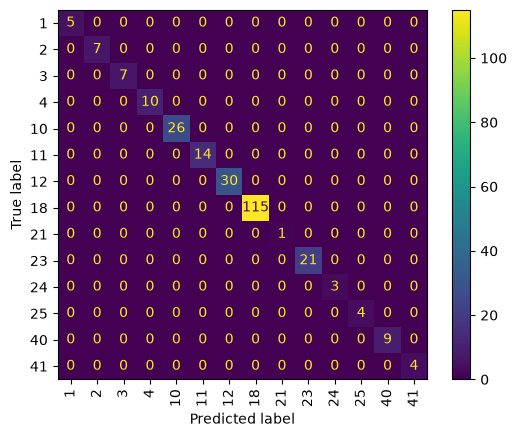

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(clf, X, y, xticks_rotation="vertical")


## Predictions (mapping)

To produce a map we read the full raster grid for a single year, stack the four
covariates into a feature matrix, predict every pixel and reshape the result back
to the 256 x 256 grid.

In [11]:
import rasterio

year = 2019
paths = [
    TOY_DIR / "static/elev.lowestmode_gedi.eml_mf_30m_s_20000101_20181231_nl_epsg.3035_v0.3.tif",
    TOY_DIR / "static/slope.percent_gedi.eml_m_30m_s_20000101_20181231_nl_epsg.3035_v0.3.tif",
    TOY_DIR / f"ndvi/filled/ndvi_landsat.ard1_p50_30m_s_{year}0321_{year}0624_nl_epsg.3035_v20230720.tif",
    TOY_DIR / f"swir1/swir1_landsat.ard1_p50_30m_s_{year}0321_{year}0624_nl_epsg.3035_v20230720.tif",
]

bands = []
for p in paths:
    with rasterio.open(p) as src:
        bands.append(src.read(1).astype("float32"))

stack = np.stack(bands, axis=-1)  # (height, width, n_features)
flat = stack.reshape(-1, len(features))
pred = clf.predict(flat)
pred_map = pred.reshape(stack.shape[:2])
pred_map.shape


(256, 256)

## Visualizing the map

Finally we plot the predicted land-cover map with
:func:`~skmap.plotter.plot_rasters`.

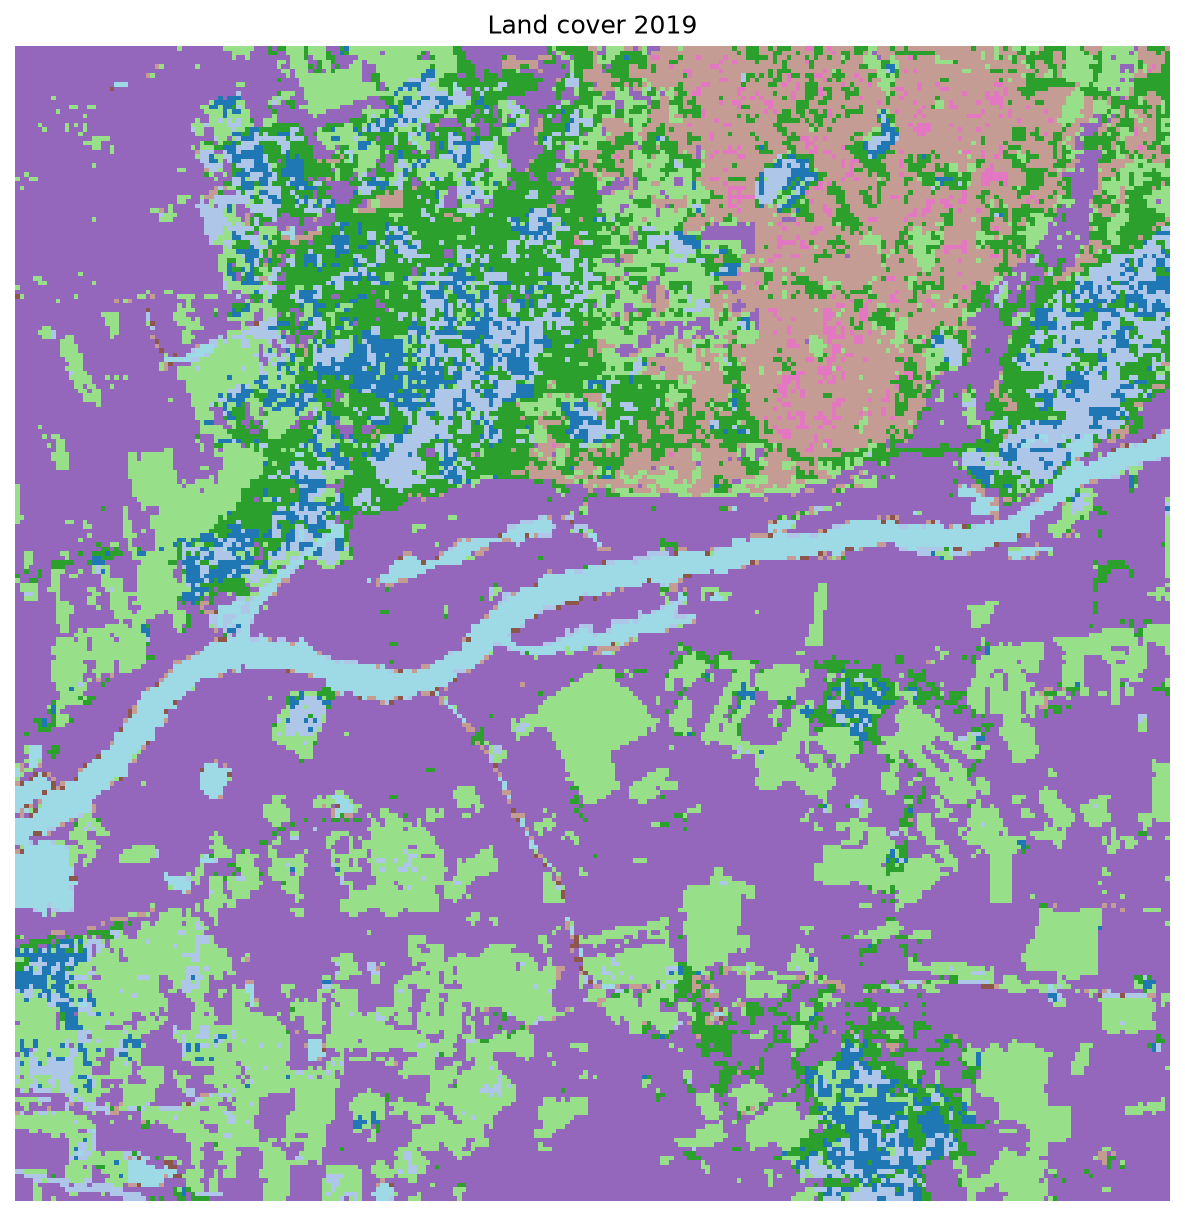

In [12]:
from skmap.plotter import plot_rasters

plot_rasters(pred_map, cmaps="tab20", titles=[f"Land cover {year}"])
